# Applying The Complete pipeline Concept 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
# Loading The data-Set 
df=pd.read_csv('../datasets/emp_sal_pred.csv')
df.sample(5)


,Age,Experience,Salary,Gender,Education,Department,Work_Mode,City,Performance,Salary_Level
8,38.0,10.0,76000.0,Male,Bachelor,IT,Hybrid,Islamabad,Average,High
5,28.0,3.0,42000.0,Female,Bachelor,Finance,Hybrid,Islamabad,Good,Low
3,40.0,12.0,NaN,Female,PhD,IT,Remote,Lahore,Excellent,High
2,NaN,8.0,72000.0,Male,Bachelor,Finance,Hybrid,Islamabad,Good,High
6,45.0,18.0,98000.0,Male,PhD,Management,Office,Lahore,Excellent,High


In [4]:
df.isnull().sum()
# age-Mean Experience-Mean and Salary-mean ma Simple Imputer laga ga 
#gender department Work_mode City  ma hum lagae ga Onehot 
# Performance ma hum Ordinal 
# salary Level ma Hum Label lagae ga 

Age             2
Experience      1
Salary          2
Gender          0
Education       0
Department      0
Work_Mode       0
City            0
Performance     0
Salary_Level    0
dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X_Train,X_Test,Y_Train,Y_Test=train_test_split(df.drop(columns=['Salary_Level']),df['Salary_Level'],test_size=0.2,random_state=42)
# print(X_Train)
# print(X_Test)

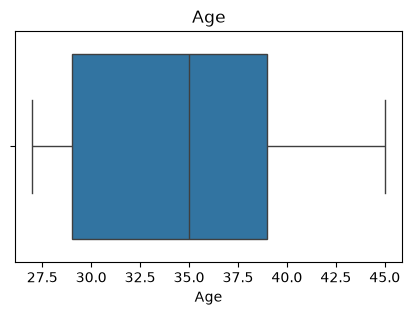

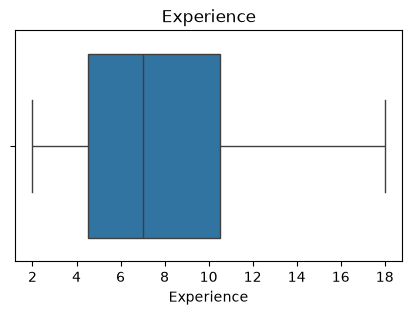

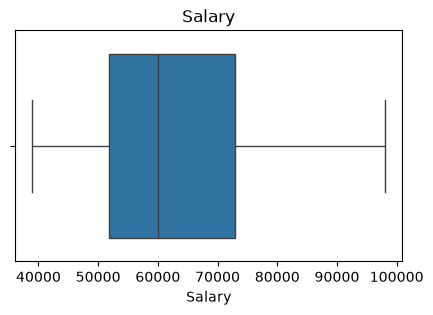

In [6]:
for col in ['Age', 'Experience', 'Salary']:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=X_Train[col])
    plt.title(col)
    plt.show()

In [7]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression

In [ ]:
df.sample(5)

,Age,Experience,Salary,Gender,Education,Department,Work_Mode,City,Performance,Salary_Level
11,27.0,2.0,39000.0,Female,Bachelor,HR,Hybrid,Islamabad,Good,Low
8,38.0,10.0,76000.0,Male,Bachelor,IT,Hybrid,Islamabad,Average,High
10,33.0,7.0,65000.0,Male,Master,Finance,Remote,Karachi,Excellent,Medium
6,45.0,18.0,98000.0,Male,PhD,Management,Office,Lahore,Excellent,High
9,29.0,4.0,NaN,Female,Bachelor,Marketing,Office,Lahore,Good,Low


In [8]:
num_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

In [9]:
nom_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
ord_pip=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ord',OrdinalEncoder(categories=[
    ['Bachelor', 'Master', 'PhD'],
    ['Average', 'Good', 'Excellent']
]))
])

In [11]:
preprocessing=ColumnTransformer([
    ('num',num_pip,["Age","Experience","Salary"]),
    ('nom',nom_pip,['Gender','Department','Work_Mode','City']),
    ('ord',ord_pip,['Education','Performance'])
])

In [12]:
model=Pipeline([
    ('preprocessing',preprocessing),
    ('model',LogisticRegression(   random_state=42,
    max_iter=1000))
])

In [13]:
from  sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
Y_Train=le.fit_transform(Y_Train)
Y_Test=le.transform(Y_Test)

In [14]:
model.fit(X_Train, Y_Train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','Experience','Salary',...,'Work_Mode','City','Performance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all

In [15]:
y_pred=model.predict(X_Test)
print(y_pred)

[2 2 1]


In [16]:
from sklearn.metrics import accuracy_score

model_accuracy=accuracy_score(Y_Test,y_pred)*100

print(f'model Accuracy is {model_accuracy} %')

model Accuracy is 66.66666666666666 %


In [17]:
from sklearn.metrics import classification_report

print(classification_report(Y_Test, y_pred))

              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_Test, y_pred)

print(cm) # YA thoeory concept ha true positive TN ,FP ,FN

[[1 1]
 [0 1]]


In [19]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_Train,
    Y_Train,
    cv=2
)

print(scores)
print(scores.mean())

[0.8  0.75]
0.775
